In [18]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import yaml
from jsonargparse import ArgumentParser

from crossgoose.data.dataset import FlowDataModule

config_file = '../configs/model_1.3.2_pxw.yaml'
with open(config_file, 'r') as f:
    full_cfg = yaml.safe_load(f)
data_cfg = {'data': full_cfg.get('data', {})}
data_cfg['data']['data_root'] = '../' + data_cfg['data']['data_root']

parser = ArgumentParser()

parser.add_class_arguments(FlowDataModule, nested_key='data')
cfg = parser.parse_string(yaml.dump(data_cfg))
data = parser.instantiate_classes(cfg).data
data.setup('fit')
train_data = data.train_dataloader()

[Dataset_v02-train] checking flows for train data: 100%|██████████| 554/554 [00:00<00:00, 354971.65it/s]


[Dataset_v02-train] no flows to (re)compute train data


[Dataset_v02-test] checking flows for test data: 100%|██████████| 179/179 [00:00<00:00, 303713.76it/s]


[Dataset_v02-test] no flows to (re)compute test data


[Dataset_v02-val] checking flows for val data: 100%|██████████| 7/7 [00:00<00:00, 42612.67it/s]

[Dataset_v02-val] no flows to (re)compute val data


{'affine': None,
 'crop': (81, 162, 256, 256),
 'flip_h': False,
 'flip_v': True,
 'patch_size': None}
{'affine': None,
 'crop': (0, 0, 256, 256),
 'flip_h': True,
 'flip_v': True,
 'patch_size': None}
{'affine': None,
 'crop': (0, 0, 256, 256),
 'flip_h': True,
 'flip_v': False,
 'patch_size': None}
{'affine': None,
 'crop': (206, 21, 256, 256),
 'flip_h': True,
 'flip_v': True,
 'patch_size': None}


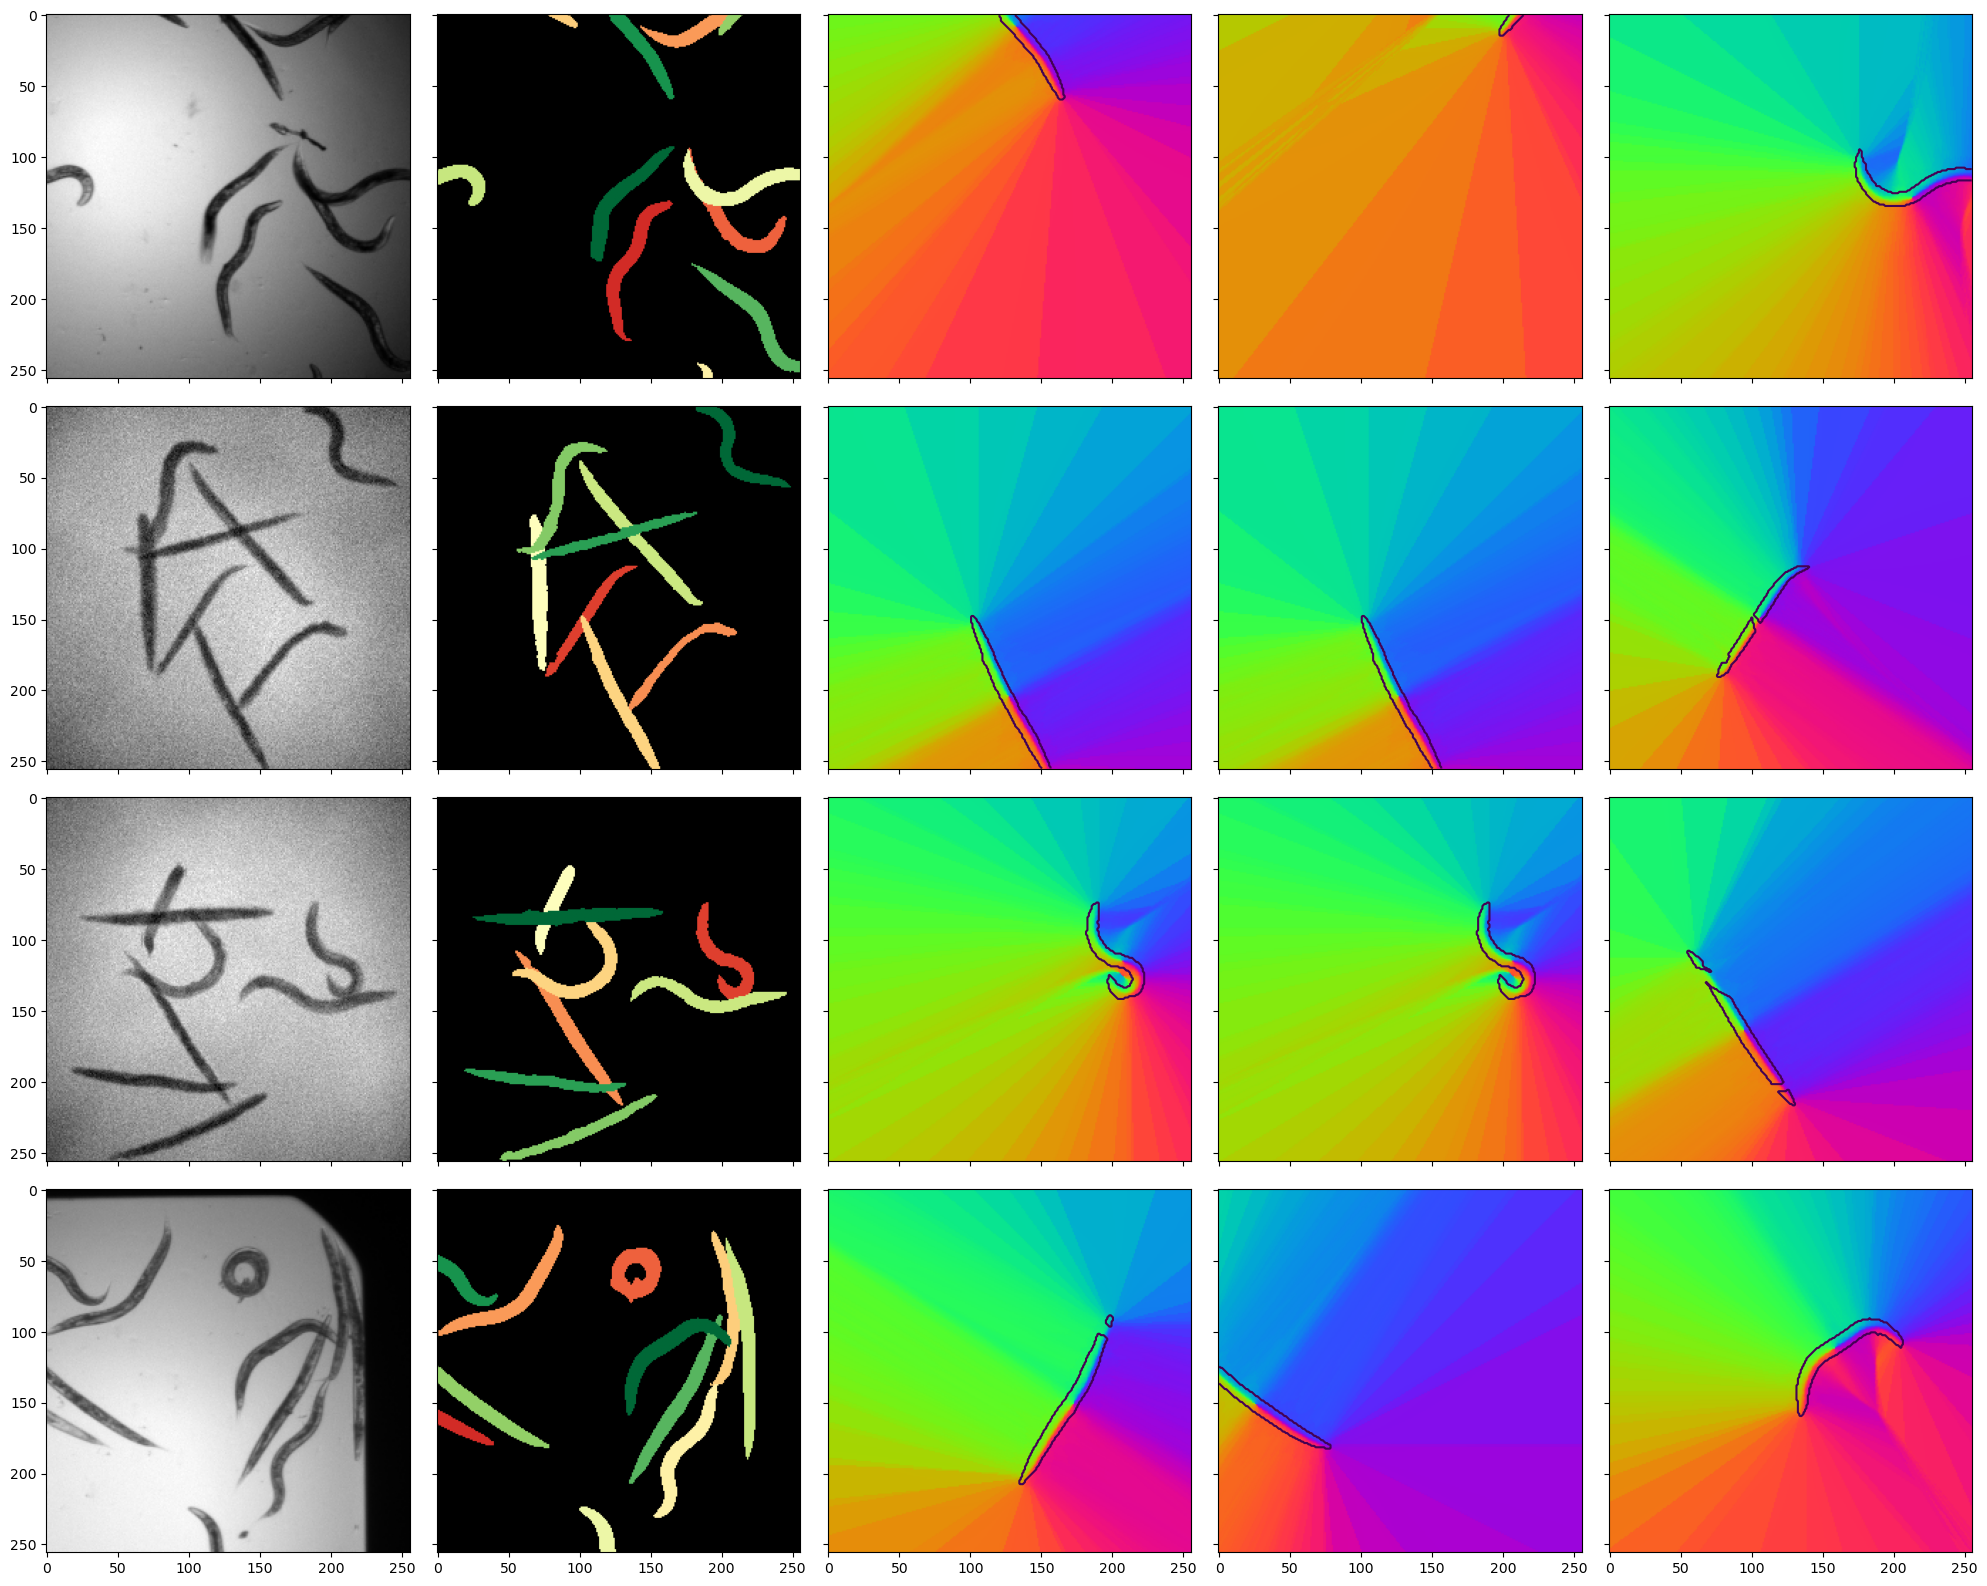

In [20]:
from pprint import pprint

from matplotlib import pyplot as plt
import numpy as np

from crossgoose.my_display import dp_to_rgb, get_custom_mask_cmap

DISP_T = ['patch_size','crop','flip_h','flip_v','affine']

batch =next(iter(train_data))
bs = len(batch['image'])
n,m = bs,5
rng = np.random.default_rng(0)
label_cmap = get_custom_mask_cmap()
fig,axs = plt.subplots(n,m,figsize=(m*4,n*4),sharex=True,sharey=True)
for i in range(bs):
    pprint({k:batch['transforms'][i].get(k,None) for k in DISP_T})
    # pprint(batch['transforms'][i])
    image = batch['image'][i,0].cpu().numpy()
    labels = batch['labels'][i].cpu().numpy()
    unique_l = list(set(np.unique(labels)) - set([0]))
    
    h,w = image.shape
    axs[i,0].imshow(image,cmap='gray')
    axs[i,1].imshow(labels,cmap=label_cmap)
    for k in range(3):
        l_pick = rng.choice(unique_l)
        m = labels==l_pick
        axs[i,2+k].contour(m)
        f = batch['flowgrid'][i].query_flow_grid(l_pick,(h,w))
        axs[i,2+k].imshow(dp_to_rgb(f))

fig.tight_layout()

pts_weights.sum()=np.float32(1.0)
pts_weights.sum()=np.float32(1.0)


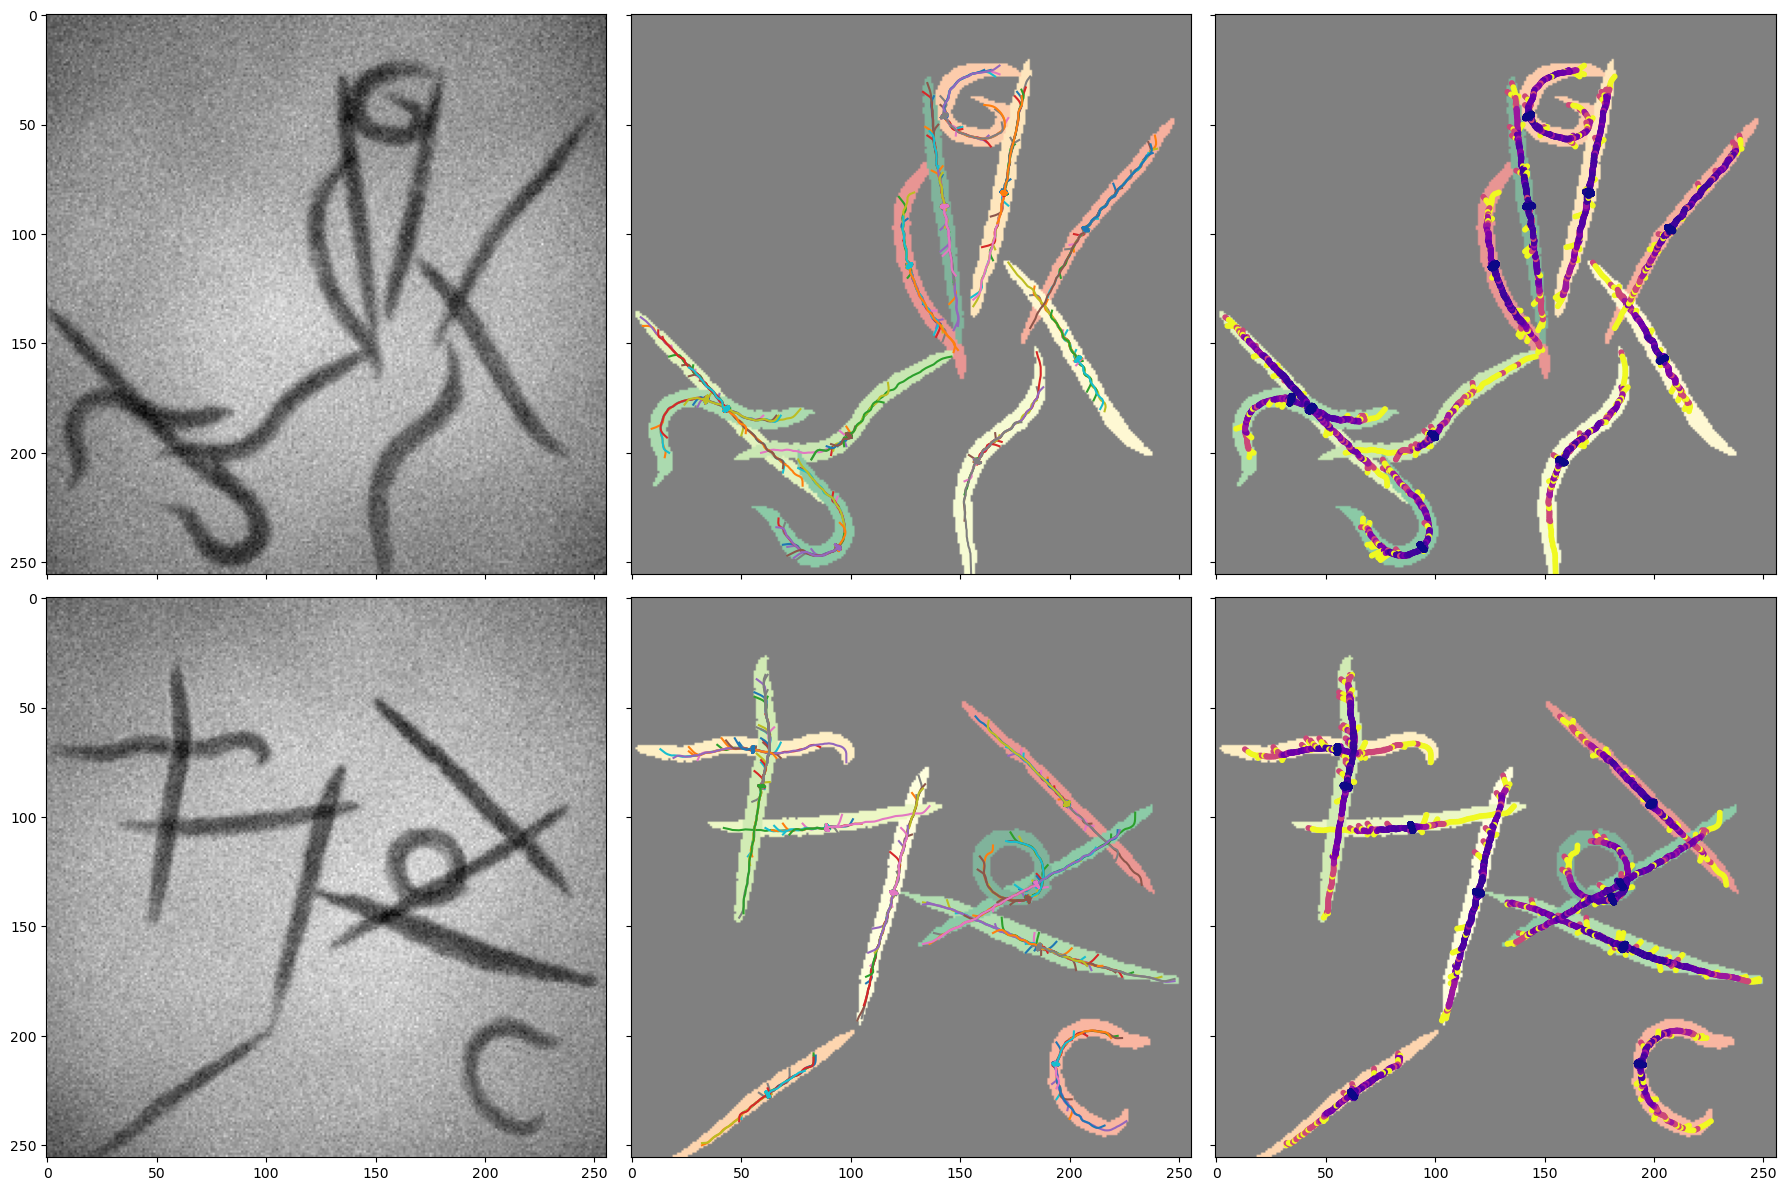

In [21]:
import torch
batch =next(iter(train_data))
bs = len(batch['image'])
n,m = 2,3
rng = np.random.default_rng(0)
label_cmap = get_custom_mask_cmap()


fig,axs = plt.subplots(n,m,figsize=(m*6,n*6),sharex=True,sharey=True)
for i in range(n):
    image = batch['image'][i,0].cpu().numpy()
    labels = batch['labels'][i].cpu().numpy()
    
    pts_batch_mask = (batch['pts_batch']==i)[:,0]
    pts_coord = batch['pts_coord'][pts_batch_mask]
    pts_flows = batch['pts_flows'][pts_batch_mask]
    pts_weights = batch['pts_weights'][pts_batch_mask].numpy()

    print(f"{pts_weights.sum()=}")

    n_samples,n_steps,_ = pts_coord.shape

    pts_flat = pts_coord.reshape((-1,2))
    wgts_flat = pts_weights.reshape((-1,))
    pts_colors = plt.get_cmap('plasma')(wgts_flat/np.max(wgts_flat))

    # subset = rng.choice(n_samples,size=100,replace=False)
    subset = slice(0,n_samples)

    axs[i,0].imshow(image,cmap='gray')
    axs[i,1].imshow(labels,cmap=label_cmap,alpha=0.5)
    axs[i,1].plot(pts_coord[subset,:,1].T,pts_coord[subset,:,0].T)
    axs[i,2].imshow(labels,cmap=label_cmap,alpha=0.5)
    axs[i,2].scatter(pts_flat[:,1],pts_flat[:,0],c=pts_colors,s=10)
    # for t in range(n_steps):
    #     axs[i,1].scatter(pts_coord[subset,t,1],pts_coord[subset,t,0],marker='.',s=20,color='tab:blue')
fig.tight_layout()

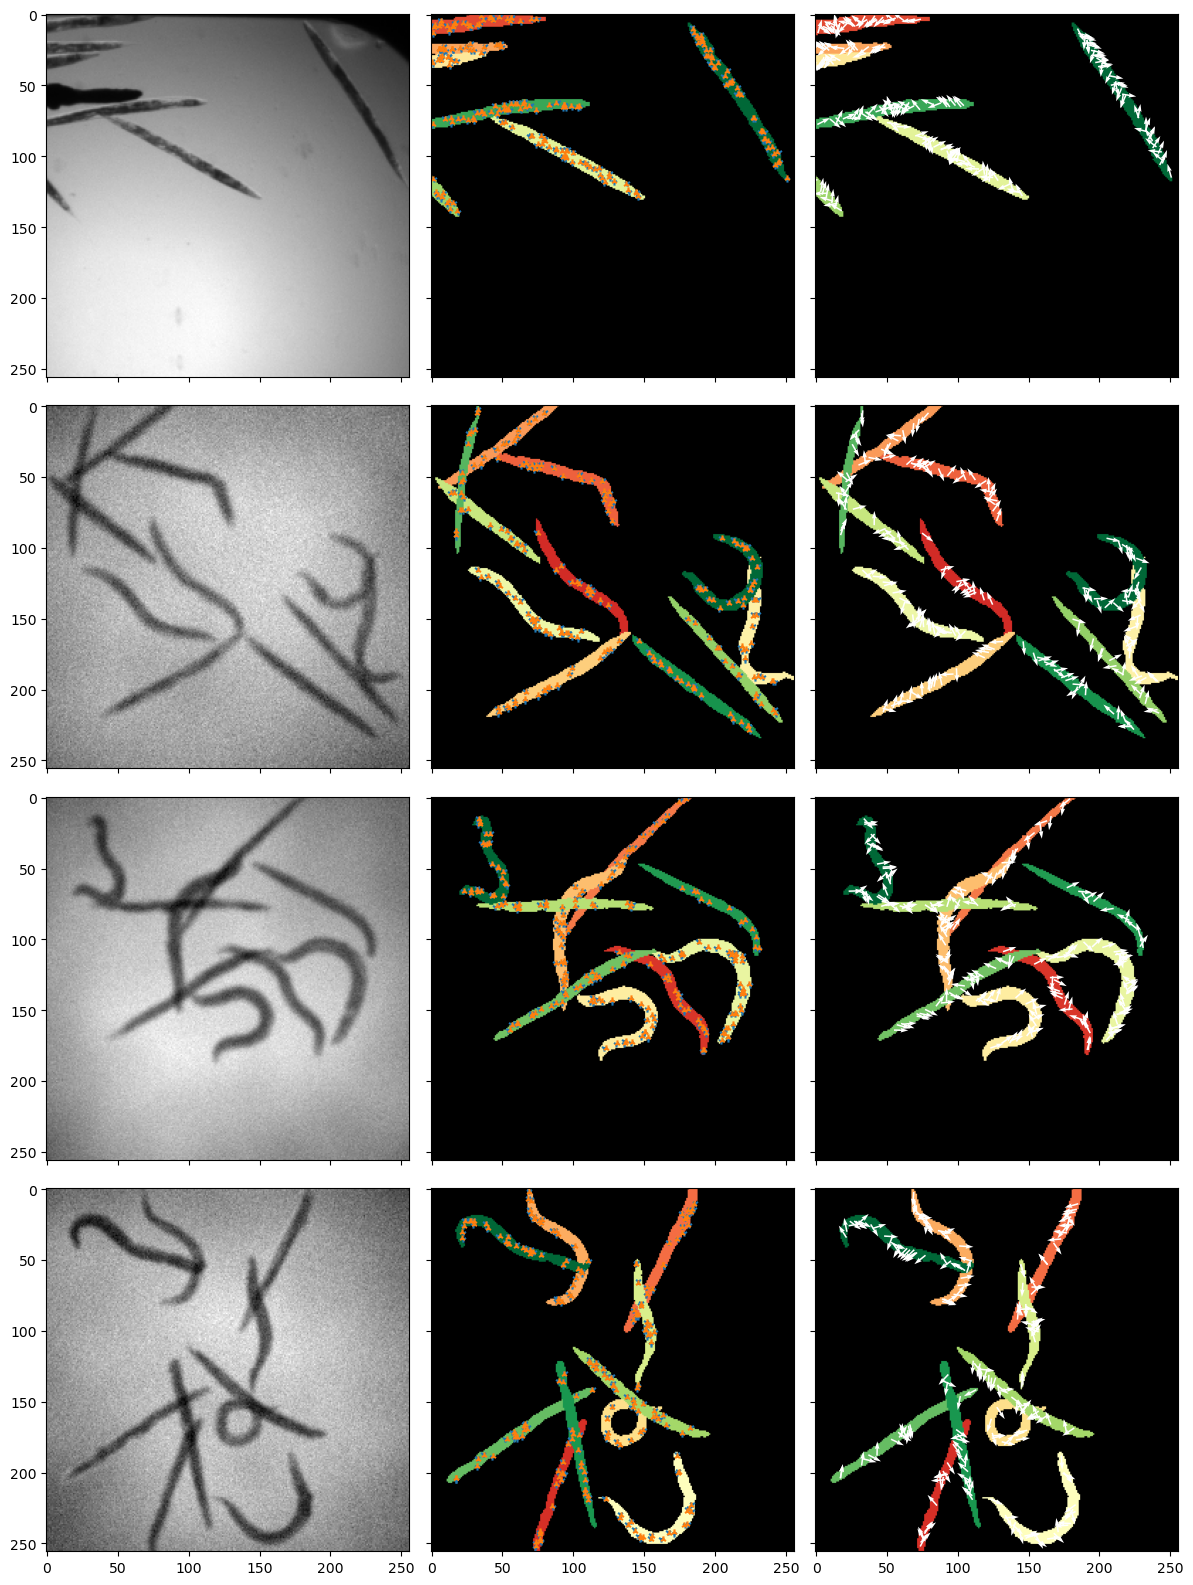

In [22]:
import torch


batch =next(iter(train_data))
bs = len(batch['image'])
n,m = bs,3
rng = np.random.default_rng(0)
label_cmap = get_custom_mask_cmap()
fig,axs = plt.subplots(n,m,figsize=(m*4,n*4),sharex=True,sharey=True)
for i in range(bs):
    image = batch['image'][i,0].cpu().numpy()
    labels = batch['labels'][i].cpu().numpy()
    
    pts_coord = batch['pts_coord']
    pts_flows = batch['pts_flows']
    pts_weights = batch['pts_weights']
    pts_batch = batch['pts_batch']

    u0 = torch.concat([pts_batch, pts_coord[:, 0]], axis=-1)
    u_mask = u0[:,0] == i
    u0 = u0[u_mask,1:].numpy()
    ut = torch.concat([pts_batch, pts_coord[:, 1]], axis=-1)
    ut = ut[u_mask,1:].numpy()
    flow_u0_ut = pts_flows[:,1][u_mask].numpy()
    
    n_pts = u0.shape[0]
    
    h,w = image.shape
    axs[i,0].imshow(image,cmap='gray')
    axs[i,1].imshow(labels,cmap=label_cmap)
    axs[i,2].imshow(labels,cmap=label_cmap)

    # subset = rng.choice(n_pts,size=800,replace=False)
    subset = slice(0,n_samples)
    axs[i,1].scatter(u0[subset,1],u0[subset,0],marker='1',s=20,color='tab:blue')
    axs[i,1].scatter(ut[subset,1],ut[subset,0],marker='2',s=20,color='tab:orange')
    axs[i,2].quiver(ut[subset,1],ut[subset,0],flow_u0_ut[subset,1],-flow_u0_ut[subset,0],color='white')
    

fig.tight_layout()